In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from functools import reduce
import numpy as np
import pandas as pd
import re
import gc
import datetime as _dt
import pyarrow.parquet as pq
from collections import defaultdict
from dateutil.relativedelta import relativedelta
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.metrics import precision_recall_curve, auc
from deap import base, creator, tools, algorithms

In [2]:
df = pd.read_csv('features_v3.csv')
df.head()

,user,email_external_ratio,email_suspicious_content_ratio,email_bcc_email_ratio,email_external_email_with_attachment_ratio,email_after_hours_or_weekend_ratio,email_max_zscore_emails,email_avg_emails_per_week,email_avg_size_sent_email,email_zscore_last_month,...,http_download_ratio,http_off_hours_ratio,http_last_month_zscore,http_max_zscore_activity,http_sus_domain_ratio,http_unique_domains,http_job_search_score,users_post_departure_activity,users_pre_departure_ratio,users_activity_not_main_pc_ratio
0,AAB0162,0.307374,0.014940,0.0,0.051176,0.000000,0.0,42.513514,1.994349e+05,-0.871931,...,0.0,0.0000,0.0,0.0,0.0318,126,0.0699,0.0,0.000000,0.0
1,AAB0398,0.383626,0.003674,0.0,0.118079,0.056416,0.0,51.500000,3.568791e+05,-0.095175,...,0.0,0.0474,0.0,0.0,0.0308,248,0.0133,0.0,0.000000,0.0
2,AAC0610,0.363118,0.009506,0.0,0.132129,0.000000,0.0,14.216216,8.273392e+05,0.315768,...,0.0,0.0096,0.0,0.0,0.1031,200,0.0189,0.0,0.001404,0.0
3,AAC0668,0.350562,0.007705,0.0,0.070305,0.000000,0.0,42.094595,4.068177e+05,0.439913,...,0.0,0.0000,0.0,0.0,0.0342,175,0.0548,0.0,0.000000,0.0
4,AAC3270,0.258721,0.000000,0.0,0.139535,0.000000,0.0,4.648649,1.333953e+06,0.901975,...,0.0,0.0000,0.0,0.0,0.0000,55,0.0045,0.0,0.000000,0.0


In [3]:
df.columns

Index(['user', 'email_external_ratio', 'email_suspicious_content_ratio',
       'email_bcc_email_ratio', 'email_external_email_with_attachment_ratio',
       'email_after_hours_or_weekend_ratio', 'email_max_zscore_emails',
       'email_avg_emails_per_week', 'email_avg_size_sent_email',
       'email_zscore_last_month', 'file_copy_ratio', 'file_write_ratio',
       'file_delete_ratio', 'file_copy_to_removable_ratio',
       'file_from_removable_ratio', 'file_events_per_file',
       'file_off_hours_ratio', 'file_suspicious_file_content_ratio',
       'file_open_then_copy_ratio', 'file_copy_then_delete_ratio',
       'file_max_zscore_file_activity', 'file_zscore_last_month',
       'logon_average_session_duration', 'logon_session_duration_variability',
       'logon_ratio_short_sessions', 'logon_used_multi_pc_simultaneously',
       'logon_unclosed_session_ratio', 'logon_after_hours_logon_ratio',
       'logon_max_zscore_logon', 'logon_max_zscore_logon_after_hours',
       'logon_zscore

In [6]:
l = pd.read_csv('insiders.csv')
insiders = l[l['dataset']==6.2]['user']
insiders

186    ACM2278
187    CMP2946
188    PLJ1771
189    CDE1846
190    MBG3183
Name: user, dtype: str

In [7]:
df['is_insider'] = df['user'].isin(insiders).astype(int)
df['is_insider'].value_counts()

is_insider
0    3995
1       5
Name: count, dtype: int64

In [8]:
X = df.drop(columns=['user','is_insider','file_open_then_copy_ratio', 'file_copy_then_delete_ratio'])

s_scaler = StandardScaler()

m_scaler = MinMaxScaler()

X_scaled_s = s_scaler.fit_transform(X)

X_scaled_m = m_scaler.fit_transform(X)

model = IsolationForest(
    n_estimators=50000,
    max_samples=2000,
    max_features=1.0,
    random_state=42
)

model.fit(X_scaled_s)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",50000
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",2000
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [9]:
df['anomaly_score'] = -model.score_samples(X_scaled_s)

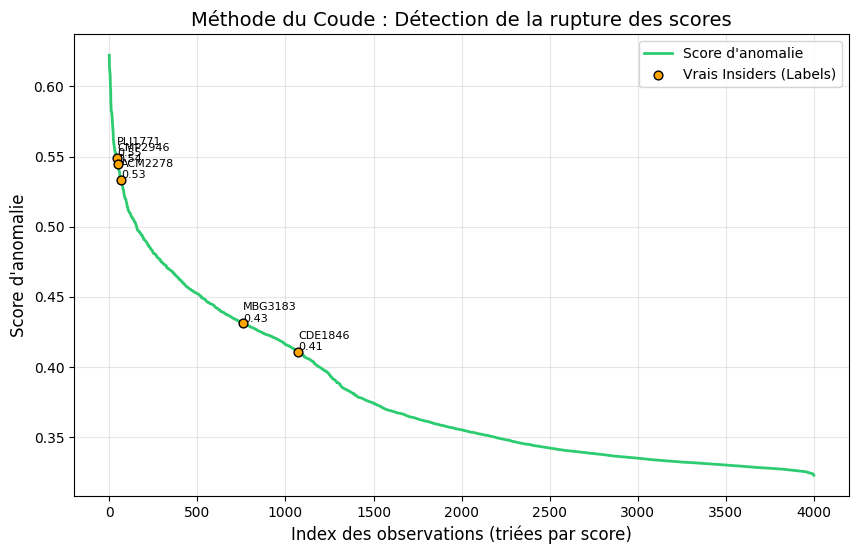

In [10]:
sorted_indices = np.argsort(df['anomaly_score'].values)[::-1]

sorted_scores = df['anomaly_score'].values[sorted_indices]

sorted_insiders = df['is_insider'].values[sorted_indices]

sorted_users = df['user'].values[sorted_indices]

insider_plot_indices = np.where(sorted_insiders == 1)[0]

plt.figure(figsize=(10, 6))

plt.plot(range(len(sorted_scores)), sorted_scores, label='Score d\'anomalie', color='#2ecc71', linewidth=2)

plt.scatter(insider_plot_indices, sorted_scores[insider_plot_indices], 
            color='orange', label='Vrais Insiders (Labels)', zorder=5, s=40, edgecolors='black')

for i in insider_plot_indices:
    user_id = sorted_users[i]
    score = sorted_scores[i]
    
    plt.text(i, score,
             f"{user_id}\n{score:.2f}",
             fontsize=8,
             ha='left',
             va='bottom')
    
plt.title("Méthode du Coude : Détection de la rupture des scores", fontsize=14)

plt.xlabel("Index des observations (triées par score)", fontsize=12)

plt.ylabel("Score d'anomalie", fontsize=12)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Genetic Algorithm

In [11]:
df = pd.read_csv('features_v3.csv')

X = df.drop(columns='user')

In [12]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [13]:
N_FEATURES = len(X.columns)
INSIDERS =  l[l['dataset']==6.2]['user']
K = 25

In [16]:
def fitness_function(individual):

    selected = [col for col, bit in zip(X.columns, individual) if bit == 1]

    if len(selected) == 0:
        return (0.0,)
    
    X_selected = X_scaled[selected]

    clf = IsolationForest(
        n_estimators=1000,
        random_state=42,
        max_samples=2000,
        max_features=1.0,
    )

    clf.fit(X_selected)
    scores = -clf.score_samples(X_selected)
    df_scores = pd.DataFrame({'user':df['user'],'score':scores})
    df_scores = df_scores.sort_values('score',ascending=False)
    df_scores['rank'] = range(1,len(df_scores)+1)

    total_users = len(df_scores)
    insider_ranks = df_scores[df_scores['user'].isin(INSIDERS)]['rank'].values

    if len(insider_ranks) == 0:
        return (0.0,)
    
    mean_rank = np.mean(insider_ranks) / total_users

    top_k_hits = np.sum(insider_ranks <= K) / len(INSIDERS)

    alpha = 0.6

    fitness = alpha * (1-mean_rank) + (1 - alpha) * top_k_hits

    return (fitness,)

In [17]:
creator.create('FitnessMax', base.Fitness, weights=(1.0,))
creator.create('Individual', list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

toolbox.register('attr_bool',np.random.randint,0,2)
toolbox.register('individual',tools.initRepeat,
                 creator.Individual, toolbox.attr_bool, n=N_FEATURES)
toolbox.register('population',tools.initRepeat,
                 list,toolbox.individual)
toolbox.register('evaluate',fitness_function)

toolbox.register('mate', tools.cxTwoPoint)
toolbox.register('mutate',tools.mutFlipBit,indpb=0.05)
toolbox.register('select',tools.selTournament,tournsize=3)

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\deap\creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


In [24]:
def run_ga(pop_size=100,n_gen=100):

    pop = toolbox.population(n=pop_size)
    hof = tools.HallOfFame(1)

    stats = tools.Statistics(lambda ind : ind.fitness.values)
    stats.register('max', np.max)
    stats.register('mean',np.mean)

    algorithms.eaSimple(
        pop, toolbox,
        cxpb=0.7, mutpb=0.2,
        ngen=n_gen,
        stats=stats,
        halloffame=hof,
        verbose=True
    )

    return hof[0]

best = run_ga()

best_features = [col for col, bit in zip(X.columns, best) if bit == 1]
print(f"Features sélectionnées ({len(best_features)}) :", best_features)
print("Fitness :", best.fitness.values[0])

gen	nevals	max    	mean    
0  	100   	0.79092	0.577205
1  	79    	0.80217	0.618139
2  	81    	0.80217	0.651428
3  	67    	0.80568	0.694372
4  	72    	0.80568	0.721929
5  	77    	0.81009	0.754411
6  	87    	0.80979	0.787984
7  	73    	0.81474	0.800434
8  	84    	0.81921	0.799622
9  	75    	0.81996	0.800167
10 	70    	0.82068	0.803072
11 	82    	0.82233	0.803301
12 	78    	0.8226 	0.800536
13 	77    	0.82314	0.804339
14 	73    	0.82536	0.810184
15 	68    	0.82899	0.814596
16 	73    	0.82899	0.816418
17 	73    	0.82851	0.811411
18 	77    	0.8289 	0.815992
19 	77    	0.83016	0.817403
20 	82    	0.83028	0.817445
21 	90    	0.83028	0.819388
22 	77    	0.83121	0.818729
23 	73    	0.83121	0.820038
24 	71    	0.83121	0.826205
25 	85    	0.83121	0.820706
26 	78    	0.91271	0.819811
27 	85    	0.91271	0.813384
28 	72    	0.91271	0.821712
29 	81    	0.91271	0.835021
30 	75    	0.91271	0.839872
31 	78    	0.91271	0.874527
32 	76    	0.9128 	0.882881
33 	73    	0.9128 	0.882608
34 	73    	0.91355	0

In [29]:
X_with_best_features = X_scaled[best_features]

model = IsolationForest(
    n_estimators=100000,
    max_samples=4000,
    max_features=1.0,
    random_state=42
)

model.fit(X_with_best_features)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100000
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",4000
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [30]:
df['anomaly_score_best_features'] = -model.score_samples(X_with_best_features)

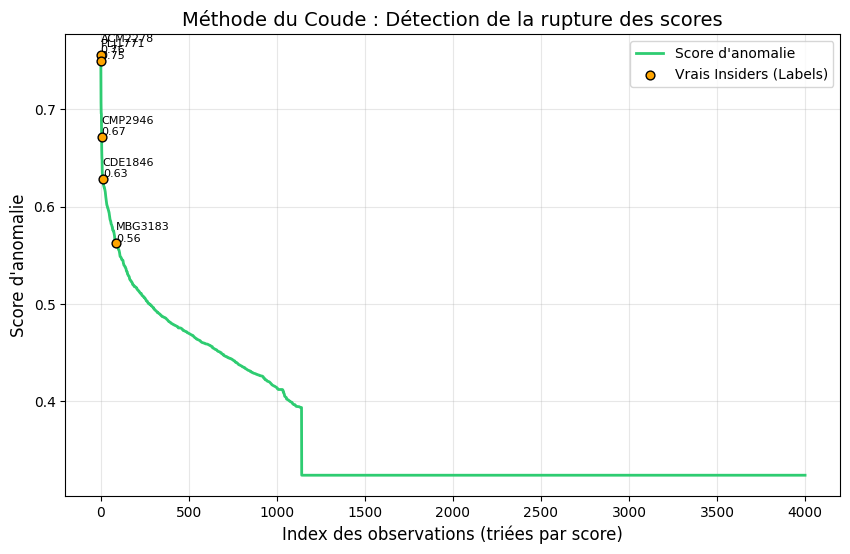

In [31]:
df['is_insider'] = df['user'].isin(insiders).astype(int)
df['is_insider'].value_counts()

sorted_indices = np.argsort(df['anomaly_score_best_features'].values)[::-1]

sorted_scores = df['anomaly_score_best_features'].values[sorted_indices]

sorted_insiders = df['is_insider'].values[sorted_indices]

sorted_users = df['user'].values[sorted_indices]

insider_plot_indices = np.where(sorted_insiders == 1)[0]

plt.figure(figsize=(10, 6))

plt.plot(range(len(sorted_scores)), sorted_scores, label='Score d\'anomalie', color='#2ecc71', linewidth=2)

plt.scatter(insider_plot_indices, sorted_scores[insider_plot_indices], 
            color='orange', label='Vrais Insiders (Labels)', zorder=5, s=40, edgecolors='black')

for i in insider_plot_indices:
    user_id = sorted_users[i]
    score = sorted_scores[i]
    
    plt.text(i, score,
             f"{user_id}\n{score:.2f}",
             fontsize=8,
             ha='left',
             va='bottom')
    
plt.title("Méthode du Coude : Détection de la rupture des scores", fontsize=14)

plt.xlabel("Index des observations (triées par score)", fontsize=12)

plt.ylabel("Score d'anomalie", fontsize=12)

plt.legend()

plt.grid(alpha=0.3)

plt.show()